# Анализ трендовых видео на YouYube в период 2020-2026

## Загрузка данных

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Запись данных в датафреймы

In [2]:
trending_videos_df = pd.read_csv('data/trending_videos.csv')
yearly_trends_df = pd.read_csv('data/yearly_trends.csv')
country_summary_df = pd.read_csv('data/country_summary.csv')
category_summary_df = pd.read_csv('data/category_summary.csv')

## Осмотр данных

## Размерность данных

### trending_videos

In [3]:
print(f"\nРазмер: {trending_videos_df.shape[0]} строк, {trending_videos_df.shape[1]} колонок")
print(f"\nКолонки:")
for col in trending_videos_df.columns:
    print(f"  • {col}")
print(f"\nТипы данных:\n{trending_videos_df.dtypes}")
print(f"\nПропуски:\n{trending_videos_df.isnull().sum()}")


Размер: 10000 строк, 34 колонок

Колонки:
  • video_id
  • title
  • title_length
  • has_caps_title
  • has_emoji_title
  • has_question_title
  • channel_name
  • subscriber_count
  • channel_verified
  • category
  • publish_date
  • trending_date
  • days_to_trend
  • year
  • month
  • day_of_week
  • trending_country
  • language
  • duration_seconds
  • views
  • likes
  • dislikes
  • comments
  • like_view_ratio_pct
  • comment_view_ratio_pct
  • engagement_score
  • tags
  • tag_count
  • description_length
  • has_links_description
  • clickbait_score
  • comments_enabled
  • caption_available
  • made_for_kids

Типы данных:
video_id                      str
title                         str
title_length                int64
has_caps_title              int64
has_emoji_title             int64
has_question_title          int64
channel_name                  str
subscriber_count            int64
channel_verified            int64
category                      str
publish_date   

### yearly_trends

In [4]:
print(f"\nРазмер: {yearly_trends_df.shape[0]} строк, {yearly_trends_df.shape[1]} колонок")
print(f"\nКолонки:")
for col in yearly_trends_df.columns:
    print(f"  • {col}")
print(f"\nТипы данных:\n{yearly_trends_df.dtypes}")
print(f"\nПропуски:\n{yearly_trends_df.isnull().sum()}")


Размер: 7 строк, 11 колонок

Колонки:
  • year
  • total_videos
  • avg_views
  • median_views
  • avg_likes
  • avg_comments
  • avg_engagement
  • avg_duration_sec
  • avg_clickbait
  • pct_verified
  • avg_subscriber_count

Типы данных:
year                      int64
total_videos              int64
avg_views               float64
median_views            float64
avg_likes               float64
avg_comments            float64
avg_engagement          float64
avg_duration_sec        float64
avg_clickbait           float64
pct_verified            float64
avg_subscriber_count    float64
dtype: object

Пропуски:
year                    0
total_videos            0
avg_views               0
median_views            0
avg_likes               0
avg_comments            0
avg_engagement          0
avg_duration_sec        0
avg_clickbait           0
pct_verified            0
avg_subscriber_count    0
dtype: int64


### country_summary

In [5]:
print(f"\nРазмер: {country_summary_df.shape[0]} строк, {country_summary_df.shape[1]} колонок")
print(f"\nКолонки:")
for col in country_summary_df.columns:
    print(f"  • {col}")
print(f"\nТипы данных:\n{country_summary_df.dtypes}")
print(f"\nПропуски:\n{country_summary_df.isnull().sum()}")


Размер: 23 строк, 7 колонок

Колонки:
  • trending_country
  • total_videos
  • avg_views
  • median_views
  • avg_engagement
  • top_category
  • avg_duration_sec

Типы данных:
trending_country        str
total_videos          int64
avg_views           float64
median_views        float64
avg_engagement      float64
top_category            str
avg_duration_sec    float64
dtype: object

Пропуски:
trending_country    0
total_videos        0
avg_views           0
median_views        0
avg_engagement      0
top_category        0
avg_duration_sec    0
dtype: int64


### category_summary

In [6]:
print(f"\nРазмер: {category_summary_df.shape[0]} строк, {category_summary_df.shape[1]} колонок")
print(f"\nКолонки:")
for col in category_summary_df.columns:
    print(f"  • {col}")
print(f"\nТипы данных:\n{category_summary_df.dtypes}")
print(f"\nПропуски:\n{category_summary_df.isnull().sum()}")


Размер: 17 строк, 11 колонок

Колонки:
  • category
  • total_videos
  • avg_views
  • median_views
  • avg_likes
  • avg_comments
  • avg_engagement
  • avg_duration_sec
  • avg_subscriber_count
  • pct_verified
  • avg_clickbait

Типы данных:
category                    str
total_videos              int64
avg_views               float64
median_views            float64
avg_likes               float64
avg_comments            float64
avg_engagement          float64
avg_duration_sec        float64
avg_subscriber_count    float64
pct_verified            float64
avg_clickbait           float64
dtype: object

Пропуски:
category                0
total_videos            0
avg_views               0
median_views            0
avg_likes               0
avg_comments            0
avg_engagement          0
avg_duration_sec        0
avg_subscriber_count    0
pct_verified            0
avg_clickbait           0
dtype: int64


#### С форматом данных всё в порядке, пропусков нет - данные готовы к анализу и не нуждаются в чистке

## Ответы на вопросы

### 1. Какие видео набирают больше всего просмотров? 

In [7]:
# Выбираем 1000 видео с самыми большими просмотрами и считаем их основные характеристики
popular_videos = trending_videos_df.nlargest(1000, 'views')

print("СТАТИСТИКА НА 1000 САМЫХ ПОПУЛЯРНЫХ ВИДЕО")
print("\nПРОИЗВОДИТЕЛЬНОСТЬ:")
print(f"  • Просмотры (медиана): {popular_videos['views'].median():,.0f}")
print(f"  • Просмотры (среднее): {popular_videos['views'].mean():,.0f}")
print(f"  • Engagement score(показатель вовлеченности): {popular_videos['engagement_score'].mean():.3f}")

print("\nВОВЛЕЧЁННОСТЬ:")
print(f"  • Like/View ratio: {popular_videos['like_view_ratio_pct'].mean():.2f}%")
print(f"  • Comment/View ratio: {popular_videos['comment_view_ratio_pct'].mean():.3f}%")
print(f"  • Среднее лайков: {popular_videos['likes'].median():,.0f}")
print(f"  • Среднее комментариев: {popular_videos['comments'].median():,.0f}")

print("\nКОНТЕНТ:")
print(f"  • Категория (мода): {popular_videos['category'].mode()[0]}")
print(f"  • Длительность (медиана): {popular_videos['duration_seconds'].median():.0f} сек "
      f"({int(popular_videos['duration_seconds'].median()//60)}:"
      f"{int(popular_videos['duration_seconds'].median()%60):02d})")
print(f"  • Кликбейт-скор (среднее): {popular_videos['clickbait_score'].mean():.3f}")
print(f"  • Эмодзи в заголовке: {popular_videos['has_emoji_title'].mean()*100:.1f}% видео")

print("\nКАНАЛ:")
print(f"  • Верифицированный канал: {popular_videos['channel_verified'].mean()*100:.1f}%")
print(f"  • Подписчики (медиана): {popular_videos['subscriber_count'].median():,.0f}")

print("\nВРЕМЯ:")
print(f"  • Дней до попадания в тренды (медиана): {popular_videos['days_to_trend'].median():.1f}")
print(f"  • Лучший день для публикации: {popular_videos['day_of_week'].mode()[0]}")


СТАТИСТИКА НА 1000 САМЫХ ПОПУЛЯРНЫХ ВИДЕО

ПРОИЗВОДИТЕЛЬНОСТЬ:
  • Просмотры (медиана): 7,392,116
  • Просмотры (среднее): 29,022,142
  • Engagement score(показатель вовлеченности): 7.435

ВОВЛЕЧЁННОСТЬ:
  • Like/View ratio: 5.45%
  • Comment/View ratio: 0.663%
  • Среднее лайков: 389,936
  • Среднее комментариев: 43,291

КОНТЕНТ:
  • Категория (мода): Music
  • Длительность (медиана): 429 сек (7:09)
  • Кликбейт-скор (среднее): 0.458
  • Эмодзи в заголовке: 3.4% видео

КАНАЛ:
  • Верифицированный канал: 97.0%
  • Подписчики (медиана): 6,178,337

ВРЕМЯ:
  • Дней до попадания в тренды (медиана): 2.0
  • Лучший день для публикации: Friday


## 2. Есть ли связь между лайками и просмотрами? 

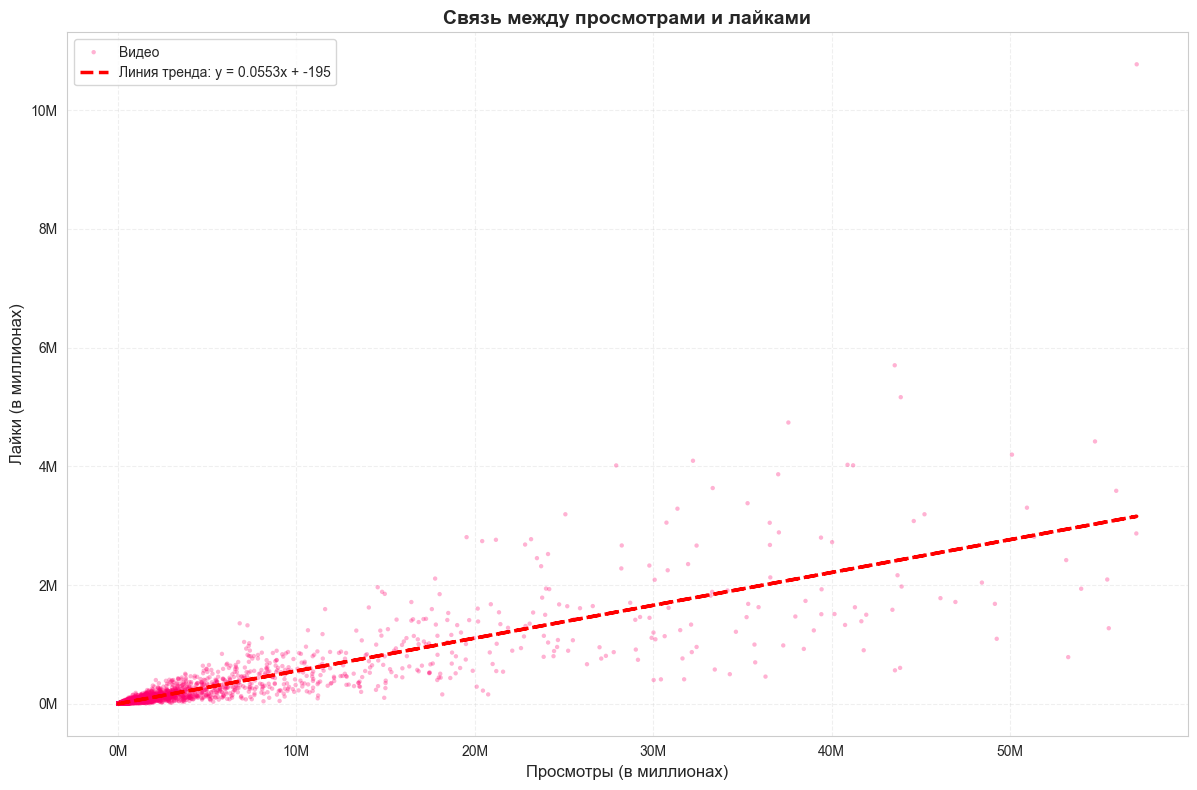

In [8]:
sns.set_style("whitegrid")

# Убираем выбросы(Всё, что больше квантиля 0.99)
df_plot = trending_videos_df[trending_videos_df['views'] <= trending_videos_df['views'].quantile(0.99)].copy()

plt.figure(figsize=(12, 8))
plt.scatter(df_plot['views'], df_plot['likes'], 
            alpha=0.3, s=10, color='#ff006e', edgecolors='none', label='Видео')

z = np.polyfit(df_plot['views'], df_plot['likes'], 1)
p = np.poly1d(z)
plt.plot(df_plot['views'], p(df_plot['views']), 
         "r--", linewidth=2.5, label=f'Линия тренда: y = {z[0]:.4f}x + {z[1]:.0f}')

plt.title('Связь между просмотрами и лайками', fontsize=14, fontweight='bold')
plt.xlabel('Просмотры', fontsize=12)
plt.ylabel('Лайки', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('images/views_vs_likes_scatter.png', dpi=300, bbox_inches='tight')

# Добавьте перед plt.show()
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    """Форматирует числа в миллионах"""
    return f'{x/1e6:.0f}M'

plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.xlabel('Просмотры (в миллионах)')
plt.ylabel('Лайки (в миллионах)')

plt.show()

In [9]:
# Коэффициент корреляции Пирсона

df = trending_videos_df
corr, p_value = df['views'].corr(df['likes']), None  # Базовый расчёт

# Более полный расчёт с p-value (через scipy)
corr, p_value = stats.pearsonr(df['views'], df['likes'])

print("КОРРЕЛЯЦИЯ: Просмотры ↔ Лайки")
print(f"Коэффициент корреляции Пирсона: {corr:+.4f}")
print(f"P-value: {p_value:.2e}")

# Интерпретация силы корреляции
if abs(corr) >= 0.8:
    strength = "Очень сильная"
elif abs(corr) >= 0.6:
    strength = "Сильная"
elif abs(corr) >= 0.4:
    strength = "Умеренная"
elif abs(corr) >= 0.2:
    strength = "Слабая"
else:
    strength = "Очень слабая"

direction = "прямая" if corr > 0 else "обратная"
print(f"\nИнтерпретация: {strength} {direction} связь")

# Проверка статистической значимости
if p_value < 0.05:
    print(f"Статистически значимо (p < 0.05)")
else:
    print(f"Не значимо (p >= 0.05)")

КОРРЕЛЯЦИЯ: Просмотры ↔ Лайки
Коэффициент корреляции Пирсона: +0.9223
P-value: 0.00e+00

Интерпретация: Очень сильная прямая связь
Статистически значимо (p < 0.05)


In [10]:
# Корреляция по топ-5 категориям

df = trending_videos_df
print("\nКОРРЕЛЯЦИЯ ПО КАТЕГОРИЯМ (топ-5):")
top_categories = df['category'].value_counts().head(5).index

for cat in top_categories:
    cat_data = df[df['category'] == cat]
    if len(cat_data) > 30:  # Минимум данных для надёжности
        cat_corr, cat_p = stats.pearsonr(cat_data['views'], cat_data['likes'])
        print(f"  {cat:20} r={cat_corr:+.3f} (n={len(cat_data)})")


КОРРЕЛЯЦИЯ ПО КАТЕГОРИЯМ (топ-5):
  Music                r=+0.921 (n=1413)
  Entertainment        r=+0.971 (n=1218)
  Gaming               r=+0.997 (n=1000)
  Sports               r=+0.928 (n=798)
  People & Blogs       r=+0.988 (n=744)


In [19]:
df = trending_videos_df

# Группировка по месяцам
monthly_counts = df.groupby('month').agg({
    'video_id': 'count',  # Количество видео
    'views': ['mean', 'median', 'sum'],
    'likes': 'mean',
    'engagement_score': 'mean'
}).round(0)

# Переименовываем колонки
monthly_counts.columns = ['total_videos', 'avg_views', 'median_views', 'total_views', 'avg_likes', 'avg_engagement']
monthly_counts = monthly_counts.reset_index()

# Добавляем названия месяцев
month_names = {
    1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
    7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт', 11: 'Ноя', 12: 'Дек'
}
monthly_counts['month_name'] = monthly_counts['month'].map(month_names)


print("СТАТИСТИКА ПО МЕСЯЦАМ:")
print(monthly_counts[['month_name', 'total_videos', 'avg_views', 'avg_likes']].to_string(index=False))

СТАТИСТИКА ПО МЕСЯЦАМ:
month_name  total_videos  avg_views  avg_likes
       Янв           988  2966326.0   130840.0
       Фев           868  2165933.0   119763.0
       Мар           924  2535300.0   165777.0
       Апр           778  2412367.0   113881.0
       Май           795  4072205.0   198301.0
       Июн           783  3259341.0   188079.0
       Июл           776  2433811.0   137580.0
       Авг           879  1451351.0    80408.0
       Сен           789  1286224.0    68720.0
       Окт           850  4960556.0   246498.0
       Ноя           789  6179342.0   323983.0
       Дек           781  3944294.0   213983.0


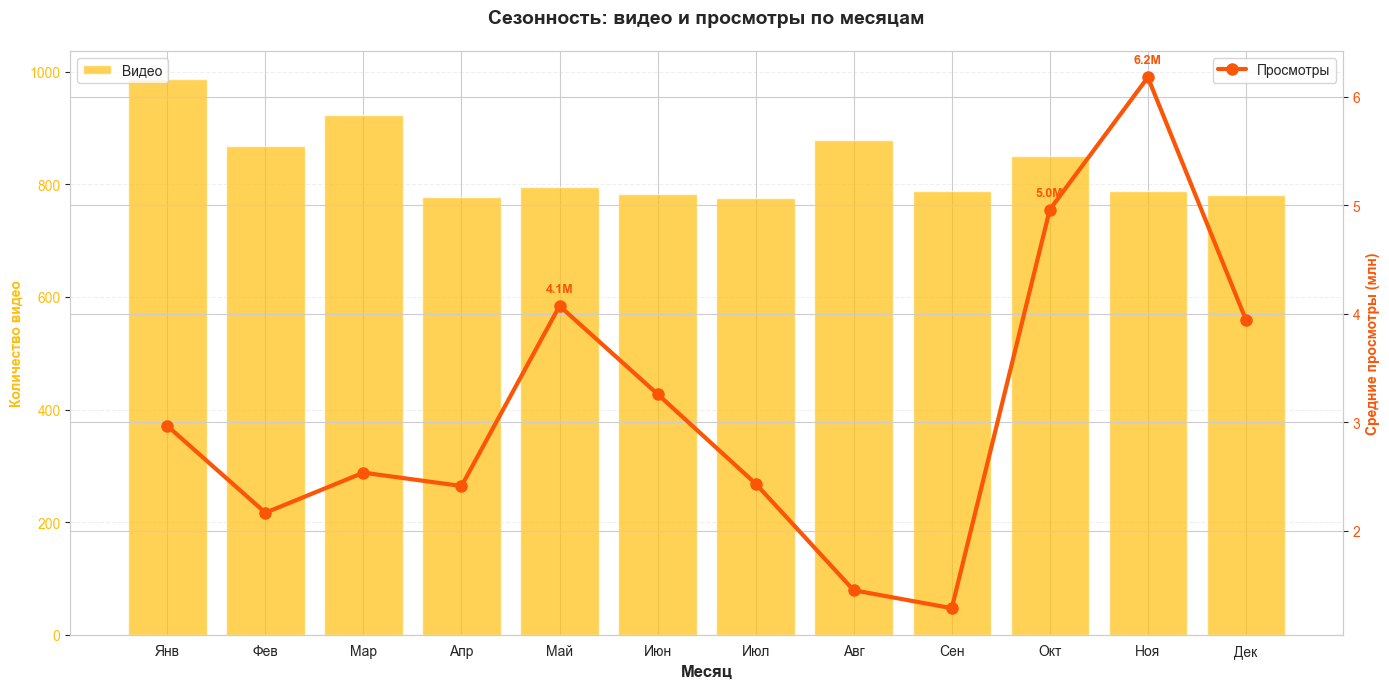

In [22]:
# Двойной график: видео + просмотры
fig, ax1 = plt.subplots(figsize=(14, 7))

# Ось 1: Количество видео
color1 = '#ffbe0b'
ax1.set_xlabel('Месяц', fontsize=12, fontweight='bold')
ax1.set_ylabel('Количество видео', color=color1, fontweight='bold')
bars = ax1.bar(monthly_counts['month_name'], monthly_counts['total_videos'], 
               color=color1, alpha=0.7, label='Видео')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Ось 2: Средние просмотры (в млн)
ax2 = ax1.twinx()
color2 = '#fb5607'
ax2.set_ylabel('Средние просмотры (млн)', color=color2, fontweight='bold')
line = ax2.plot(monthly_counts['month_name'], monthly_counts['avg_views']/1e6, 
                color=color2, linewidth=3, marker='o', markersize=8, label='Просмотры')
ax2.tick_params(axis='y', labelcolor=color2)

# Заголовок и легенда
plt.title('Сезонность: видео и просмотры по месяцам', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Подписи пиков
for i, row in monthly_counts.iterrows():
    if row['avg_views'] > 4e6:  # Подписать месяцы с >4 млн просмотров
        ax2.annotate(f"{row['avg_views']/1e6:.1f}M", 
                     (row['month_name'], row['avg_views']/1e6),
                     textcoords="offset points", xytext=(0,10), ha='center',
                     fontsize=9, fontweight='bold', color=color2)

fig.tight_layout()
plt.savefig('images/seasonality_double.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
print("АНАЛИЗ: Предпочтения по странам")


# Проверяем колонку со странами
print(f"\nУникальные страны: {df['trending_country'].nunique()}")
print(f"Список стран:\n{df['trending_country'].value_counts()}")

# Базовая статистика по странам
country_stats = df.groupby('trending_country').agg({
    'video_id': 'count',
    'views': ['mean', 'median'],
    'likes': 'mean',
    'engagement_score': 'mean',
    'category': lambda x: x.value_counts().index[0]  # Самая популярная категория
}).round(0)

country_stats.columns = ['total_videos', 'avg_views', 'median_views', 'avg_likes', 'avg_engagement', 'top_category']
country_stats = country_stats.reset_index()

print(f"\nСтатистика по странам (топ-10):")
print(country_stats.nlargest(10, 'total_videos')[
    ['trending_country', 'total_videos', 'avg_views', 'top_category']
].to_string(index=False))

АНАЛИЗ: Предпочтения по странам

Уникальные страны: 23
Список стран:
trending_country
US    2584
IN    1478
BR     791
GB     701
MX     511
JP     400
DE     399
FR     368
CA     297
ID     292
KR     285
RU     279
TH     221
VN     219
PH     211
AU     197
TR     184
PK     107
EG     100
AR      97
NG      95
CO      95
SA      89
Name: count, dtype: int64

Статистика по странам (топ-10):
trending_country  total_videos  avg_views top_category
              US          2584  2375599.0        Music
              IN          1478  4052084.0        Music
              BR           791  3769374.0        Music
              GB           701  2900274.0        Music
              MX           511  3666630.0        Music
              JP           400  3759463.0        Music
              DE           399  2081565.0        Music
              FR           368  2107512.0        Music
              CA           297  3442694.0        Music
              ID           292  2733084.0        Mus

In [29]:

print("ТОП КАТЕГОРИЙ ПО СТРАНАМ (сортировка по популярности):")

# 1️Считаем количество видео по странам и сортируем по убыванию
top_countries = df['trending_country'].value_counts().head(10).index

print(f"Топ-10 стран по количеству видео: {list(top_countries)}")

# 2️Для каждой страны показываем топ-3 категории
for country in top_countries:
    country_data = df[df['trending_country'] == country]
    top_cats = country_data['category'].value_counts().head(3)
    
    print(f"\n🇺🇳 {country}:")
    for i, (cat, count) in enumerate(top_cats.items(), 1):
        pct = count / len(country_data) * 100
        print(f"  {i}. {cat:20} {count:4} видео ({pct:.1f}%)")

ТОП КАТЕГОРИЙ ПО СТРАНАМ (сортировка по популярности):
Топ-10 стран по количеству видео: ['US', 'IN', 'BR', 'GB', 'MX', 'JP', 'DE', 'FR', 'CA', 'ID']

🇺🇳 US:
  1. Music                 369 видео (14.3%)
  2. Entertainment         336 видео (13.0%)
  3. Gaming                260 видео (10.1%)

🇺🇳 IN:
  1. Music                 205 видео (13.9%)
  2. Entertainment         196 видео (13.3%)
  3. Gaming                137 видео (9.3%)

🇺🇳 BR:
  1. Music                 109 видео (13.8%)
  2. Entertainment          87 видео (11.0%)
  3. Gaming                 86 видео (10.9%)

🇺🇳 GB:
  1. Music                 104 видео (14.8%)
  2. Entertainment          75 видео (10.7%)
  3. Gaming                 69 видео (9.8%)

🇺🇳 MX:
  1. Music                  87 видео (17.0%)
  2. Entertainment          64 видео (12.5%)
  3. Sports                 47 видео (9.2%)

🇺🇳 JP:
  1. Music                  60 видео (15.0%)
  2. Entertainment          48 видео (12.0%)
  3. Gaming                 38 видео (9.

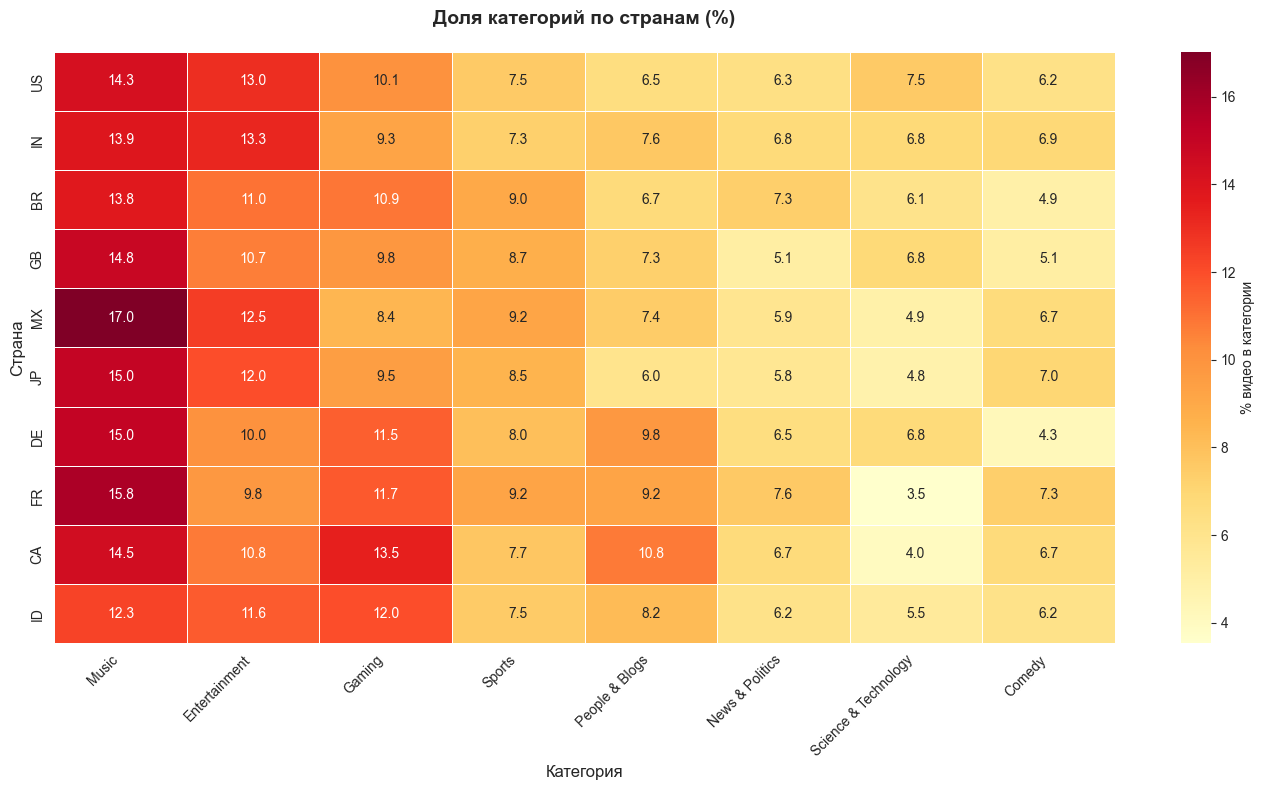

In [31]:
# Сводная таблица: страны × категории
category_country = pd.crosstab(
    df['trending_country'], 
    df['category'],
    normalize='index'  # Проценты внутри каждой страны
) * 100

# Берём топ-10 стран и топ-8 категорий
top_countries = df['trending_country'].value_counts().head(10).index
top_categories = df['category'].value_counts().head(8).index

heatmap_data = category_country.loc[top_countries, top_categories]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': '% видео в категории'})

plt.title('Доля категорий по странам (%)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Страна', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/categories_by_country.png', dpi=300, bbox_inches='tight')
plt.show()